FR
  animal  1: 40 modes from FR_t00_40_45_r00_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r01_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r02_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r03_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r04_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r05_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r06_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r07_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r08_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t00_40_45_r09_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_49_r00_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_49_r01_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_49_r02_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_49_r03_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_49_r04_1_overlaps_eigs.pkl
  animal  1: 40 modes from FR_t01_44_

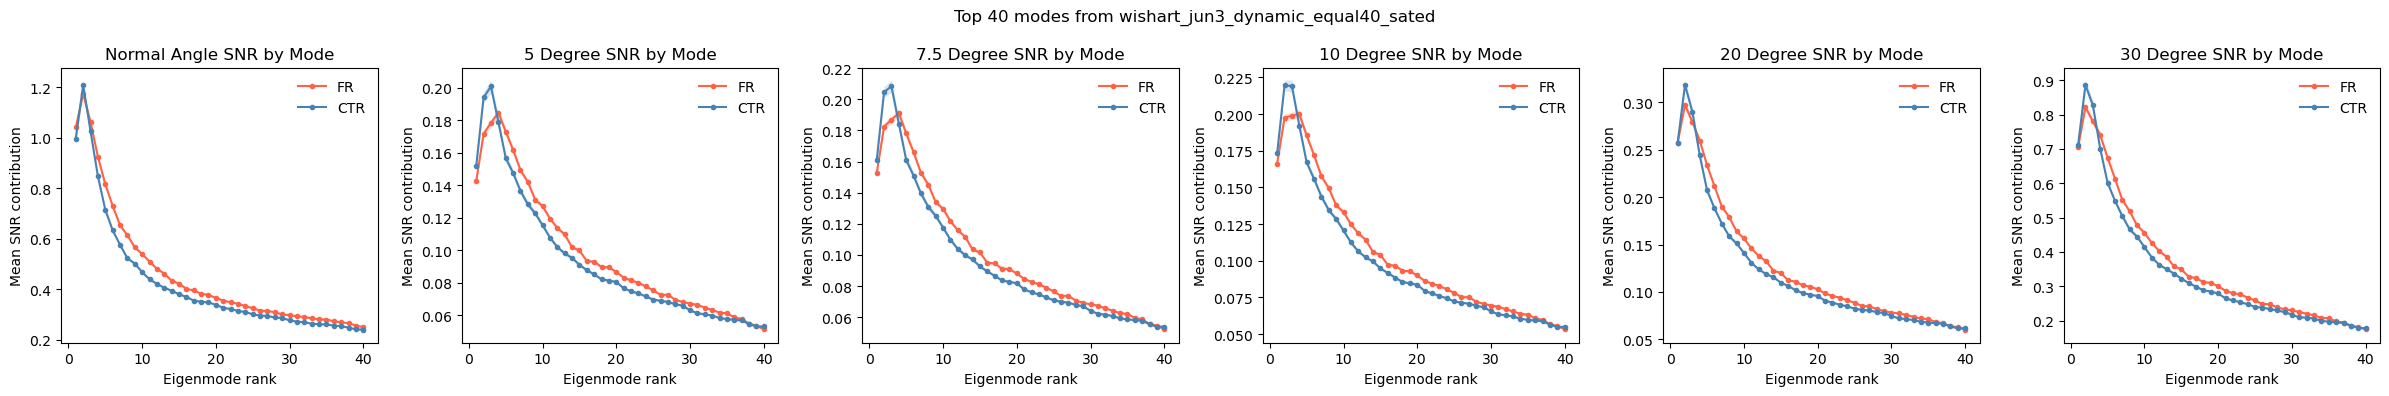

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Settings
# ----------------------------
RESULTS_DIR = Path("wishart_raw_mu_gp_interp_jun2_static_equal40_sated")  # change if needed
RESULTS_DIR = Path("wishart_jun3_dynamic_equal40_sated")  # change if needed
RESULT_DIR = Path("wishart_jun8_static_equal40_sated")


N_MODES = 40

GROUPS = ["FR", "CTR"]
COLORS = {"FR": "tomato", "CTR": "steelblue"}

# ----------------------------
# Load one group
# ----------------------------
def load_group_mode_snr(prefix, folder=RESULTS_DIR, n_modes=N_MODES):
    rows = []

    files = sorted(Path(folder).glob(f"{prefix}_*_overlaps_eigs.pkl"))
    if not files:
        raise FileNotFoundError(f"No files found for {prefix} in {folder}")

    for path in files:
        with open(path, "rb") as f:
            d = pickle.load(f)

        animal = int(d["animal"])

        overlaps = np.asarray(d["overlaps_per_condition"], dtype=float)
        eigs = np.asarray(d["eigs_per_condition"], dtype=float)
        overlaps_small = np.asarray(d["overlaps_small"], dtype=float)

        # Shape checks:
        # overlaps:       (angles, angle_pairs, sfs, modes, repeats)
        # eigs:           (angles, sfs, modes, repeats)
        # overlaps_small: (small_angles, angles, sfs, modes, repeats)

        available_modes = eigs.shape[2]
        if available_modes < n_modes:
            raise ValueError(
                f"{path.name} only has {available_modes} modes, "
                f"but n_modes={n_modes}. Lower N_MODES."
            )

        # Keep only common top modes.
        overlaps = overlaps[:, :, :, :n_modes, :]
        eigs = eigs[:, :, :n_modes, :]
        overlaps_small = overlaps_small[:, :, :, :n_modes, :]

        eigs_pos = np.where(eigs > 0, eigs, np.nan)

        # Per-mode SNR contribution.
        # normal_snr_modes: (angles, angle_pairs, sfs, modes, repeats)
        normal_snr_modes = overlaps / eigs_pos[:, None, :, :, :]

        # small_snr_modes: (small_angles, angles, sfs, modes, repeats)
        small_snr_modes = overlaps_small / eigs_pos[None, ...]

        # Reduce everything except mode.
        normal_by_mode = np.nanmean(normal_snr_modes, axis=(0, 1, 2, 4))
        small_by_mode = np.nanmean(small_snr_modes, axis=(1, 2, 4))

        rows.append({
            "animal": animal,
            "normal_by_mode": normal_by_mode,
            "small_by_mode": small_by_mode,
            "n_available_modes": available_modes,
            "small_angles": np.asarray(d["small_angle"], dtype=float),
            "file": path.name,
        })

    rows.sort(key=lambda r: r["animal"])
    return rows


def mean_sem_by_mode(rows, key):
    arr = np.stack([r[key] for r in rows], axis=0)  # animals x modes
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
    return mean, sem, arr


# ----------------------------
# Load data
# ----------------------------
group_rows = {
    group: load_group_mode_snr(group, RESULTS_DIR, N_MODES)
    for group in GROUPS
}

for group, rows in group_rows.items():
    print(group)
    for r in rows:
        print(f"  animal {r['animal']:2d}: {r['n_available_modes']} modes from {r['file']}")

# ----------------------------
# Plot
# ----------------------------
mode_idx = np.arange(1, N_MODES + 1)

small_angles = group_rows[GROUPS[0]][0]["small_angles"]
fig, axes = plt.subplots(1, 1 + len(small_angles), figsize=(4 * (1 + len(small_angles)), 4), sharex=True)

for ax, small_idx, title in [
    (axes[0], None, "Normal Angle SNR by Mode"),
    *[(axes[i + 1], i, f"{angle:g} Degree SNR by Mode") for i, angle in enumerate(small_angles)],
]:
    for group in GROUPS:
        mean, sem, _ = mean_sem_by_mode(group_rows[group], "normal_by_mode" if small_idx is None else "small_by_mode")
        if small_idx is not None:
            mean = mean[small_idx]
            sem = sem[small_idx]

        ax.plot(mode_idx, mean, marker="o", markersize=3, color=COLORS[group], label=group)
        ax.fill_between(
            mode_idx,
            mean - sem,
            mean + sem,
            color=COLORS[group],
            alpha=0.2,
            linewidth=0,
        )

    ax.set_title(title)
    ax.set_xlabel("Eigenmode rank")
    ax.set_ylabel("Mean SNR contribution")
    ax.legend(frameon=False)

plt.suptitle(f"Top {N_MODES} modes from {RESULTS_DIR.name}")
plt.tight_layout()
plt.show()

FR animals: [ 1  2  3  6  7  8 11 12]
CTR animals: [ 0  4  5  9 10 13]
FR_overlaps: (8, 10, 12, 11, 5, 40, 1)
FR_eigs: (8, 10, 12, 5, 40, 1)
CTR_overlaps: (6, 10, 12, 11, 5, 40, 1)
CTR_eigs: (6, 10, 12, 5, 40, 1)
small angles: [ 5.   7.5 10.  20.  30. ]


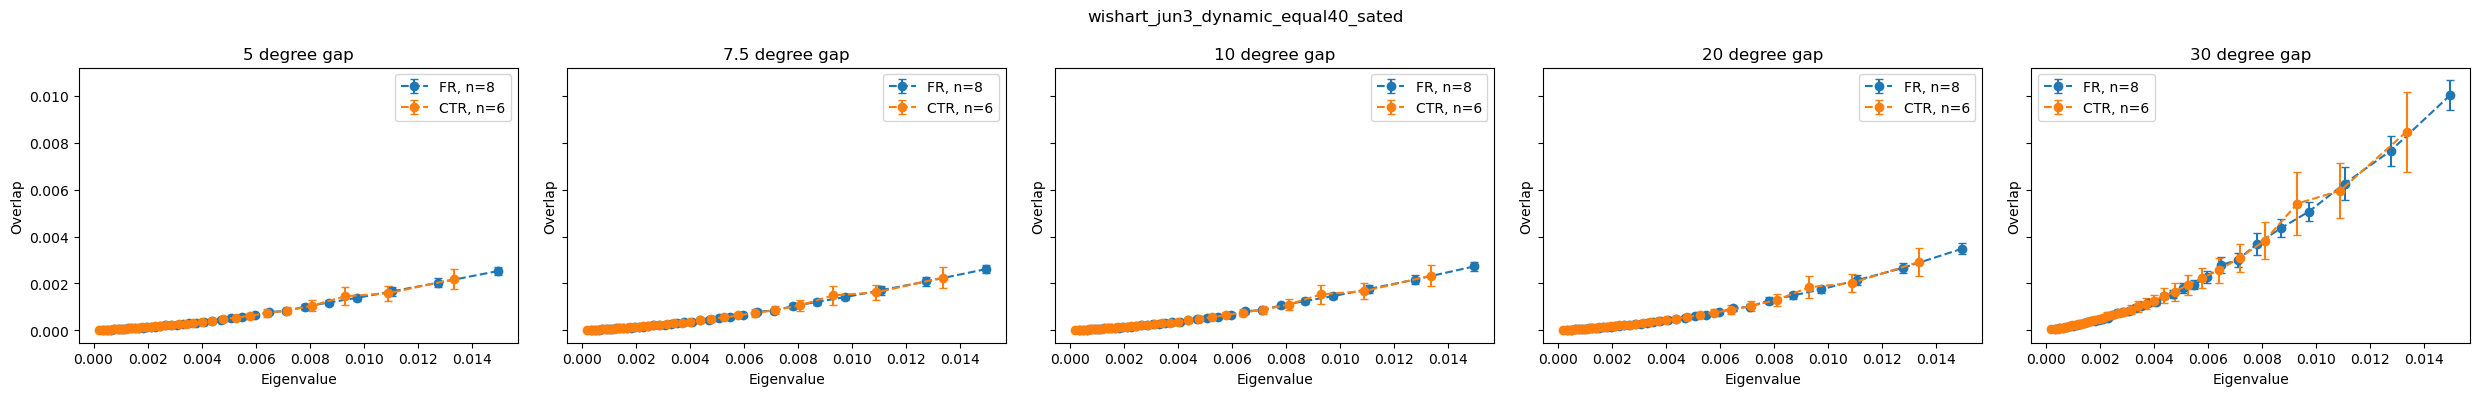

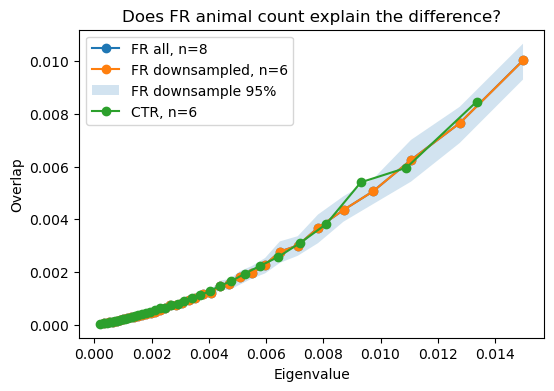

FR per-animal mean overlap: {np.int64(1): np.float64(0.0024770173938624316), np.int64(2): np.float64(0.002240002227579448), np.int64(3): np.float64(0.0016339952319413633), np.int64(6): np.float64(0.0018547900123559828), np.int64(7): np.float64(0.0011585770048181878), np.int64(8): np.float64(0.0015954718838281738), np.int64(11): np.float64(0.0018905582445108812), np.int64(12): np.float64(0.001261474006751249)}
CTR per-animal mean overlap: {np.int64(0): np.float64(0.0025858769876411763), np.int64(4): np.float64(0.0013622074208640158), np.int64(5): np.float64(0.0011730093270987702), np.int64(9): np.float64(0.0008630309724667618), np.int64(10): np.float64(0.0006161726362485004), np.int64(13): np.float64(0.0014333446082372377)}


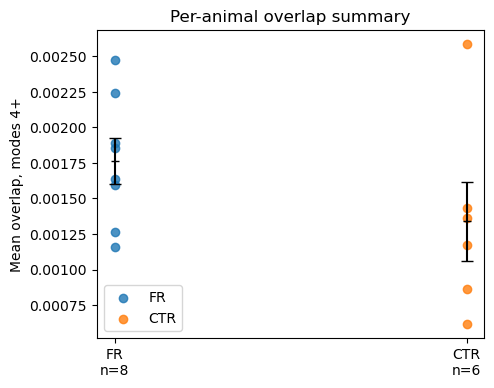

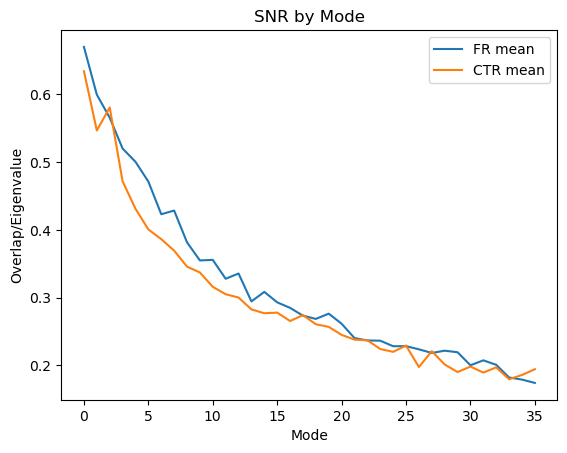

In [2]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

# DATA_FOLDER = "wishart_may30_static_equal40_sated"
DATA_FOLDER = RESULTS_DIR
def load_equal40_group(prefix, folder=DATA_FOLDER):
    rows = []

    for f in Path(folder).glob(f"{prefix}_*_overlaps_eigs.pkl"):
        with open(f, "rb") as fh:
            d = pickle.load(fh)

        parts = f.stem.replace("_overlaps_eigs", "").split("_")
        repeat_idx = int([p for p in parts if p.startswith("r") and p[1:].isdigit()][0][1:])
        animal = int(d["animal"])
        rows.append((animal, repeat_idx, f.stem.replace("_overlaps_eigs", ""), d))

    if not rows:
        raise FileNotFoundError(f"No {prefix} files found in {folder}")

    animals = np.array(sorted({animal for animal, _, _, _ in rows}))
    repeats = np.array(sorted({repeat_idx for _, repeat_idx, _, _ in rows}))
    lookup = {(animal, repeat_idx): d for animal, repeat_idx, _, d in rows}

    missing = [
        (animal, repeat_idx)
        for animal in animals
        for repeat_idx in repeats
        if (animal, repeat_idx) not in lookup
    ]
    if missing:
        raise ValueError(f"Missing animal/repeat files: {missing[:10]}")

    overlaps = np.stack([
        np.stack([
            np.asarray(lookup[(animal, repeat_idx)]["overlaps_per_condition"])
            for repeat_idx in repeats
        ], axis=0)
        for animal in animals
    ], axis=0)

    eigs = np.stack([
        np.stack([
            np.asarray(lookup[(animal, repeat_idx)]["eigs_per_condition"])
            for repeat_idx in repeats
        ], axis=0)
        for animal in animals
    ], axis=0)

    overlaps_small = np.stack([
        np.stack([
            np.asarray(lookup[(animal, repeat_idx)]["overlaps_small"])
            for repeat_idx in repeats
        ], axis=0)
        for animal in animals
    ], axis=0)

    small_angles = np.asarray(rows[0][3]["small_angle"], dtype=float)
    return animals, repeats, overlaps, eigs, overlaps_small, small_angles


def nansem(x, axis=0):
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    return sd / np.sqrt(n)


angle_gap_idx = 0
mode_start = 4
plot_small = True

FR_animals, FR_repeats, FR_overlaps, FR_eigs, FR_overlaps_small, small_angles = load_equal40_group("FR")
CTR_animals, CTR_repeats, CTR_overlaps, CTR_eigs, CTR_overlaps_small, ctr_small_angles = load_equal40_group("CTR")
np.testing.assert_array_equal(small_angles, ctr_small_angles)

print("FR animals:", FR_animals)
print("CTR animals:", CTR_animals)
print("FR_overlaps:", FR_overlaps.shape)
print("FR_eigs:", FR_eigs.shape)
print("CTR_overlaps:", CTR_overlaps.shape)
print("CTR_eigs:", CTR_eigs.shape)
print("small angles:", small_angles)

def curves_by_animal(overlaps, eigs, overlaps_small):
    overlap_by_animal = np.nanmean(
        overlaps[:, :, :, angle_gap_idx, :, :, :],
        axis=(1, 2, 3, 5),
    )  # (animals, modes)

    eigs_by_animal = np.nanmean(
        eigs,
        axis=(1, 2, 3, 5),
    )  # (animals, modes), averaged over SFs too

    overlap_small_by_animal = np.nanmean(
        overlaps_small,
        axis=(1, 3, 4, 6),
    )  # (animals, small_angles, modes)

    return overlap_by_animal, eigs_by_animal, overlap_small_by_animal


fr_overlap_by_animal, fr_eigs_by_animal, fr_small_by_animal = curves_by_animal(
    FR_overlaps, FR_eigs, FR_overlaps_small
)
ctr_overlap_by_animal, ctr_eigs_by_animal, ctr_small_by_animal = curves_by_animal(
    CTR_overlaps, CTR_eigs, CTR_overlaps_small
)

fr_overlap_mean = np.nanmean(fr_overlap_by_animal, axis=0)
fr_overlap_err = nansem(fr_overlap_by_animal, axis=0)
fr_eigs_mean = np.nanmean(fr_eigs_by_animal, axis=0)

ctr_overlap_mean = np.nanmean(ctr_overlap_by_animal, axis=0)
ctr_overlap_err = nansem(ctr_overlap_by_animal, axis=0)
ctr_eigs_mean = np.nanmean(ctr_eigs_by_animal, axis=0)

fr_small_mean = np.nanmean(fr_small_by_animal, axis=0)
fr_small_err = nansem(fr_small_by_animal, axis=0)

ctr_small_mean = np.nanmean(ctr_small_by_animal, axis=0)
ctr_small_err = nansem(ctr_small_by_animal, axis=0)

sl = slice(mode_start, None)

if not plot_small:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(
        fr_eigs_mean[sl],
        fr_overlap_mean[sl],
        yerr=fr_overlap_err[sl],
        marker="o",
        capsize=3,
        label=f"FR, n={len(FR_animals)}",
    )

    ax.errorbar(
        ctr_eigs_mean[sl],
        ctr_overlap_mean[sl],
        yerr=ctr_overlap_err[sl],
        marker="o",
        capsize=3,
        label=f"CTR, n={len(CTR_animals)}",
    )
    ax.set_title(DATA_FOLDER)
    axes = [ax]

else:
    fig, axes = plt.subplots(1, len(small_angles), figsize=(5 * len(small_angles), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for small_idx, (ax, angle) in enumerate(zip(axes, small_angles)):
        ax.errorbar(
            fr_eigs_mean[sl],
            fr_small_mean[small_idx, sl],
            yerr=fr_small_err[small_idx, sl],
            marker="o",
            capsize=3,
            linestyle="--",
            label=f"FR, n={len(FR_animals)}",
        )
        ax.errorbar(
            ctr_eigs_mean[sl],
            ctr_small_mean[small_idx, sl],
            yerr=ctr_small_err[small_idx, sl],
            marker="o",
            capsize=3,
            linestyle="--",
            label=f"CTR, n={len(CTR_animals)}",
        )
        ax.set_title(f"{angle:g} degree gap")

for ax in axes:
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Overlap")
    ax.legend()
fig.suptitle(DATA_FOLDER)
plt.tight_layout()
plt.show()


# Group-size sanity check: downsample FR to match CTR animal count.
rng = np.random.default_rng(13)
n_boot = 5000
n_ctr = len(CTR_animals)

fr_down_overlap = []
fr_down_eigs = []

for _ in range(n_boot):
    idx = rng.choice(len(FR_animals), size=n_ctr, replace=False)
    fr_down_overlap.append(np.nanmean(fr_overlap_by_animal[idx], axis=0))
    fr_down_eigs.append(np.nanmean(fr_eigs_by_animal[idx], axis=0))

fr_down_overlap = np.asarray(fr_down_overlap)
fr_down_eigs = np.asarray(fr_down_eigs)

fr_down_overlap_mean = np.nanmean(fr_down_overlap, axis=0)
fr_down_overlap_lo, fr_down_overlap_hi = np.nanpercentile(fr_down_overlap, [2.5, 97.5], axis=0)
fr_down_eigs_mean = np.nanmean(fr_down_eigs, axis=0)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    fr_eigs_mean[sl],
    fr_overlap_mean[sl],
    "o-",
    label=f"FR all, n={len(FR_animals)}",
)

ax.plot(
    fr_down_eigs_mean[sl],
    fr_down_overlap_mean[sl],
    "o-",
    label=f"FR downsampled, n={n_ctr}",
)

ax.fill_between(
    fr_down_eigs_mean[sl],
    fr_down_overlap_lo[sl],
    fr_down_overlap_hi[sl],
    alpha=0.2,
    label="FR downsample 95%",
)

ax.plot(
    ctr_eigs_mean[sl],
    ctr_overlap_mean[sl],
    "o-",
    label=f"CTR, n={len(CTR_animals)}",
)

ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Overlap")
ax.set_title("Does FR animal count explain the difference?")
ax.legend()
plt.show()


# Per-animal diagnostic dots.
fr_animal_summary = np.nanmean(fr_overlap_by_animal[:, sl], axis=1)
ctr_animal_summary = np.nanmean(ctr_overlap_by_animal[:, sl], axis=1)

print("FR per-animal mean overlap:", dict(zip(FR_animals, fr_animal_summary)))
print("CTR per-animal mean overlap:", dict(zip(CTR_animals, ctr_animal_summary)))

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(
    np.zeros_like(fr_animal_summary),
    fr_animal_summary,
    alpha=0.8,
    label="FR",
)

ax.scatter(
    np.ones_like(ctr_animal_summary),
    ctr_animal_summary,
    alpha=0.8,
    label="CTR",
)

ax.errorbar(
    [0],
    [np.nanmean(fr_animal_summary)],
    yerr=[nansem(fr_animal_summary)],
    fmt="k_",
    capsize=4,
)

ax.errorbar(
    [1],
    [np.nanmean(ctr_animal_summary)],
    yerr=[nansem(ctr_animal_summary)],
    fmt="k_",
    capsize=4,
)

ax.set_xticks([0, 1])
ax.set_xticklabels([f"FR\nn={len(FR_animals)}", f"CTR\nn={len(CTR_animals)}"])
ax.set_ylabel(f"Mean overlap, modes {mode_start}+")
ax.set_title("Per-animal overlap summary")
ax.legend()
plt.show()

plt.plot(fr_overlap_mean[sl]/fr_eigs_mean[sl], label="FR mean")
plt.plot(ctr_overlap_mean[sl]/ctr_eigs_mean[sl], label="CTR mean")
plt.xlabel("Mode")
plt.ylabel("Overlap/Eigenvalue")
plt.title("SNR by Mode")
plt.legend()
plt.show()


# Raw Overlaps

/tmp/ipykernel_163418/2778746140.py:31: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(raw, axis=-1).transpose(3, 1, 2, 0)  # trials x angles x sfs x neurons


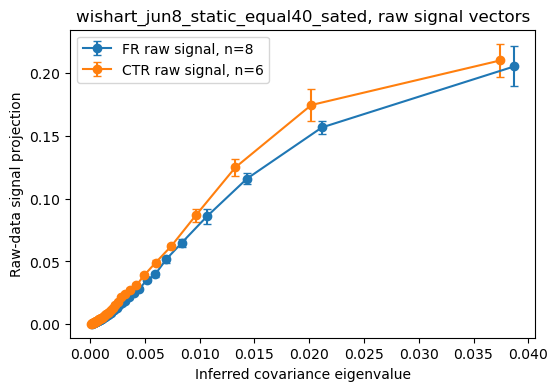

FR raw signal norm mean: 0.32427501409835763
CTR raw signal norm mean: 0.2969431017387858


In [15]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

import z_castedo_snr_script_dynamic as base

DATA_FOLDER = "wishart_jun8_static_equal40_sated"
DATASET_STATE = "sated"

angle_gap_idx = 0
mode_start = 0
normalize_overlap = False  # set True for dot^2 / ||raw signal||^2

base.DATASET_STATE = DATASET_STATE
deconv, angle, sf = base.load_state_inputs()


def nansem(x, axis=0):
    n = np.sum(np.isfinite(x), axis=axis)
    return np.nanstd(x, axis=axis, ddof=1) / np.sqrt(n)


def raw_condition_means_for_saved_run(d):
    animal = int(d["animal"])
    start = int(d["start"])
    stop = int(d["stop"])
    neuron_indices = np.asarray(d["neuron_indices"], dtype=int)

    raw = base.resort_preprocessing(deconv, angle, sf, animal)[:, :, :, :, start:stop]
    resp = np.nanmean(raw, axis=-1).transpose(3, 1, 2, 0)  # trials x angles x sfs x neurons
    resp = resp[~np.isnan(resp).any(axis=(1, 2, 3))]

    resp = resp[..., neuron_indices]
    raw_mean = np.nanmean(resp, axis=0)  # angles x sfs x selected_neurons

    return raw_mean


def raw_overlap_and_eigs_for_file(path):
    with open(path, "rb") as fh:
        d = pickle.load(fh)

    raw_mean = raw_condition_means_for_saved_run(d)
    covs = np.asarray(d["sigma_orig_mode"])       # (angles*sfs, neurons, neurons)
    eigs_saved = np.asarray(d["eigs_per_condition"])

    c1, c2, n_neurons = raw_mean.shape
    covs = covs.reshape(c1, c2, n_neurons, n_neurons)

    kmax = eigs_saved.shape[2]
    raw_overlap = np.full((c1, c2, kmax), np.nan)
    raw_norm = np.full((c1, c2), np.nan)
    raw_eigs = np.full((c1, c2, kmax), np.nan)

    for ia in range(c1):
        ja = (ia + angle_gap_idx + 1) % c1

        for isf in range(c2):
            sv = raw_mean[ia, isf, :] - raw_mean[ja, isf, :]
            raw_norm[ia, isf] = np.linalg.norm(sv)

            evals, evecs = np.linalg.eigh(covs[ia, isf])
            order = np.argsort(evals)[::-1]
            evals = evals[order]
            evecs = evecs[:, order]

            raw_eigs[ia, isf, :] = evals[:kmax]

            for k in range(kmax):
                dot2 = np.dot(sv, evecs[:, k]) ** 2
                if normalize_overlap:
                    dot2 = dot2 / (raw_norm[ia, isf] ** 2)
                sv_norm_sq = np.dot(sv, sv)

                if sv_norm_sq > 0:
                    raw_overlap[ia, isf, k] = (
                        np.dot(sv, evecs[:, k]) ** 2 / sv_norm_sq
                    )
                # raw_overlap[ia, isf, k] = dot2

    return int(d["animal"]), int(d["repeat_idx"]), raw_overlap, raw_eigs, raw_norm


def load_raw_overlap_group(prefix, folder=DATA_FOLDER):
    rows = []

    for path in Path(folder).glob(f"{prefix}_*_overlaps_eigs.pkl"):
        animal, repeat_idx, overlap, eigs, norm = raw_overlap_and_eigs_for_file(path)
        rows.append((animal, repeat_idx, overlap, eigs, norm))

    rows.sort(key=lambda x: (x[0], x[1]))

    animals = np.array(sorted({animal for animal, _, _, _, _ in rows}))
    repeats = np.array(sorted({repeat_idx for _, repeat_idx, _, _, _ in rows}))

    lookup = {(animal, repeat_idx): (overlap, eigs, norm)
              for animal, repeat_idx, overlap, eigs, norm in rows}

    overlaps = np.stack([
        np.stack([lookup[(animal, repeat_idx)][0] for repeat_idx in repeats], axis=0)
        for animal in animals
    ], axis=0)
    # animals x file_repeats x angles x sfs x modes

    eigs = np.stack([
        np.stack([lookup[(animal, repeat_idx)][1] for repeat_idx in repeats], axis=0)
        for animal in animals
    ], axis=0)
    # animals x file_repeats x angles x sfs x modes

    norms = np.stack([
        np.stack([lookup[(animal, repeat_idx)][2] for repeat_idx in repeats], axis=0)
        for animal in animals
    ], axis=0)
    # animals x file_repeats x angles x sfs

    return animals, repeats, overlaps, eigs, norms


FR_animals, FR_repeats, FR_raw_overlap, FR_raw_eigs, FR_raw_norms = load_raw_overlap_group("FR")
CTR_animals, CTR_repeats, CTR_raw_overlap, CTR_raw_eigs, CTR_raw_norms = load_raw_overlap_group("CTR")

fr_overlap_by_animal = np.nanmean(FR_raw_overlap, axis=(1, 2, 3))  # animals x modes
fr_eigs_by_animal = np.nanmean(FR_raw_eigs, axis=(1, 2, 3))        # animals x modes


ctr_overlap_by_animal = np.nanmean(CTR_raw_overlap, axis=(1, 2, 3))
ctr_eigs_by_animal = np.nanmean(CTR_raw_eigs, axis=(1, 2, 3))
ctr_norms_by_animal = np.nanmean(CTR_raw_norms, axis=(1, 2, 3))

fr_overlap_mean = np.nanmean(fr_overlap_by_animal, axis=0)
fr_overlap_err = nansem(fr_overlap_by_animal, axis=0)


fr_eigs_mean = np.nanmean(fr_eigs_by_animal, axis=0)

ctr_overlap_mean = np.nanmean(ctr_overlap_by_animal, axis=0)
ctr_overlap_err = nansem(ctr_overlap_by_animal, axis=0)

ctr_cos_2_mean = np.nanmean(ctr_overlap_by_animal / ctr_norms_by_animal[:, np.newaxis], axis=0)
ctr_cos_2_err = nansem(ctr_overlap_by_animal / ctr_norms_by_animal[:, np.newaxis], axis=0)

ctr_eigs_mean = np.nanmean(ctr_eigs_by_animal, axis=0)

sl = slice(mode_start, None)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    fr_eigs_mean[sl],
    fr_overlap_mean[sl],
    yerr=fr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"FR raw signal, n={len(FR_animals)}",
)

ax.errorbar(
    ctr_eigs_mean[sl],
    ctr_overlap_mean[sl],
    yerr=ctr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"CTR raw signal, n={len(CTR_animals)}",
)



ax.set_xlabel("Inferred covariance eigenvalue")
ax.set_ylabel("Raw-data signal projection" + (" / raw signal norm²" if normalize_overlap else ""))
ax.set_title(f"{DATA_FOLDER}, raw signal vectors")
ax.legend()
plt.show()

print("FR raw signal norm mean:", np.nanmean(FR_raw_norms))
print("CTR raw signal norm mean:", np.nanmean(CTR_raw_norms))

<ErrorbarContainer object of 3 artists>

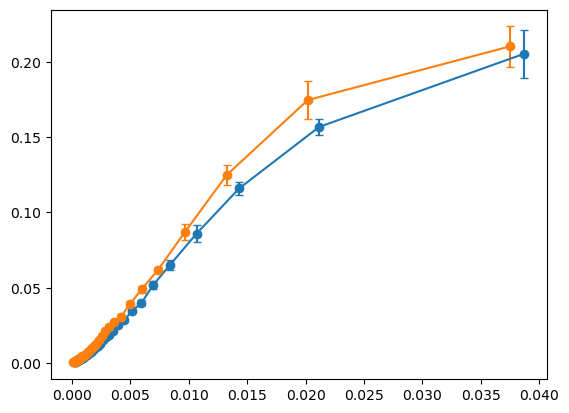

In [14]:
fr_cos2_by_animal = np.nanmean(FR_raw_overlap, axis=(1, 2, 3))
ctr_cos2_by_animal = np.nanmean(CTR_raw_overlap, axis=(1, 2, 3))

fr_cos_2_mean = np.nanmean(fr_cos2_by_animal, axis=0)
fr_cos_2_err = nansem(fr_cos2_by_animal, axis=0)

ctr_cos_2_mean = np.nanmean(ctr_cos2_by_animal, axis=0)
ctr_cos_2_err = nansem(ctr_cos2_by_animal, axis=0)

plt.errorbar(
    fr_eigs_mean[sl],
    fr_cos_2_mean[sl],
    yerr=fr_cos_2_err[sl],
    marker="o",
    capsize=3,
    label=f"FR raw signal, n={len(FR_animals)}",
)
plt.errorbar(
    ctr_eigs_mean[sl],
    ctr_cos_2_mean[sl],
    yerr=ctr_cos_2_err[sl],
    marker="o",
    capsize=3,
    label=f"CTR raw signal, n={len(CTR_animals)}",
)

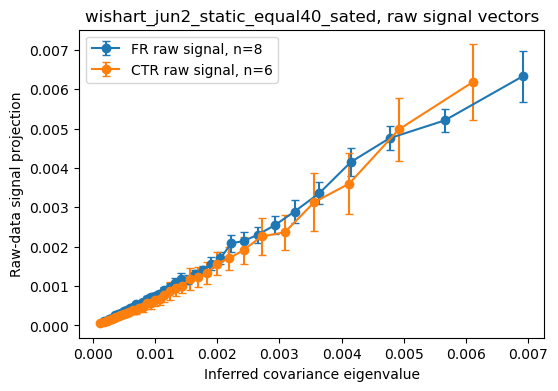

FR raw signal norm mean: 0.32427501409835763
CTR raw signal norm mean: 0.2969431017387858


In [5]:
mode_start = 4
sl = slice(mode_start, None)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    fr_eigs_mean[sl],
    fr_overlap_mean[sl],
    yerr=fr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"FR raw signal, n={len(FR_animals)}",
)

ax.errorbar(
    ctr_eigs_mean[sl],
    ctr_overlap_mean[sl],
    yerr=ctr_overlap_err[sl],
    marker="o",
    capsize=3,
    label=f"CTR raw signal, n={len(CTR_animals)}",
)

ax.set_xlabel("Inferred covariance eigenvalue")
ax.set_ylabel("Raw-data signal projection" + (" / raw signal norm²" if normalize_overlap else ""))
ax.set_title(f"{DATA_FOLDER}, raw signal vectors")
ax.legend()
plt.show()

print("FR raw signal norm mean:", np.nanmean(FR_raw_norms))
print("CTR raw signal norm mean:", np.nanmean(CTR_raw_norms))

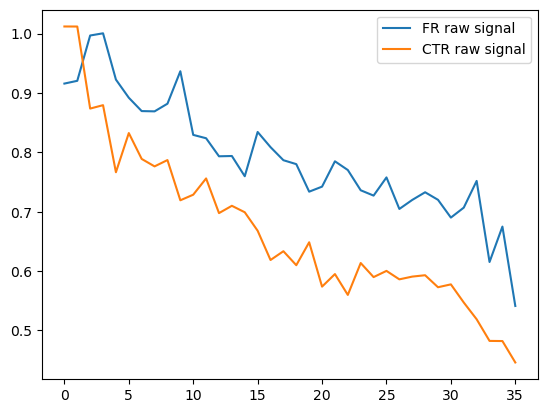

In [7]:
plt.plot(fr_overlap_mean[sl]/fr_eigs_mean[sl], label="FR raw signal")
plt.plot(ctr_overlap_mean[sl]/ctr_eigs_mean[sl], label="CTR raw signal")
plt.legend()

In [ ]:
snr_mode_start = 0  # use mode_start here if you want to drop early modes

def total_snr_by_animal(overlaps_small, eigs, mode_start=0):
    eigs_pos = np.where(eigs > 0, eigs, np.nan)
    snr_modes = (
        overlaps_small[..., mode_start:, :]
        / eigs_pos[:, :, None, :, :, mode_start:, :]
    )
    total_snr = np.nansum(snr_modes, axis=-2)  # sum over modes
    return np.nanmean(total_snr, axis=(1, 3, 4, 5))  # animals x angle gaps

def mean_sem(x):
    n = np.sum(np.isfinite(x), axis=0)
    return np.nanmean(x, axis=0), np.nanstd(x, axis=0, ddof=1) / np.sqrt(n)

fr_total_snr = total_snr_by_animal(FR_overlaps_small, FR_eigs, snr_mode_start)
ctr_total_snr = total_snr_by_animal(CTR_overlaps_small, CTR_eigs, snr_mode_start)

fig, ax = plt.subplots(figsize=(5.5, 4))
for label, values, color in [
    ("FR", fr_total_snr, "tomato"),
    ("CTR", ctr_total_snr, "steelblue"),
]:
    mean, sem = mean_sem(values)
    ax.errorbar(
        small_angles,
        mean,
        yerr=sem,
        marker="o",
        capsize=3,
        color=color,
        label=f"{label}, n={values.shape[0]}",
    )

ax.set_xlabel("Angle gap (degrees)")
ax.set_ylabel("Total SNR")
snr_title_folder = Path(RESULTS_DIR).name if "RESULTS_DIR" in globals() else str(DATA_FOLDER)
ax.set_title(f"{snr_title_folder}, modes {snr_mode_start + 1}+")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


wishart_may30_static_equal40_sated: processing 140 files
wishart_may31_static_equal40_sated: processing 140 files
wishart_jun1_static_equal40_sated: processing 140 files
wishart_jun2_static_equal40_sated: processing 140 files
wishart_raw_mu_gp_interp_jun2_static_equal40_sated: processing 140 files
wishart_jun8_static_equal40_sated: processing 140 files


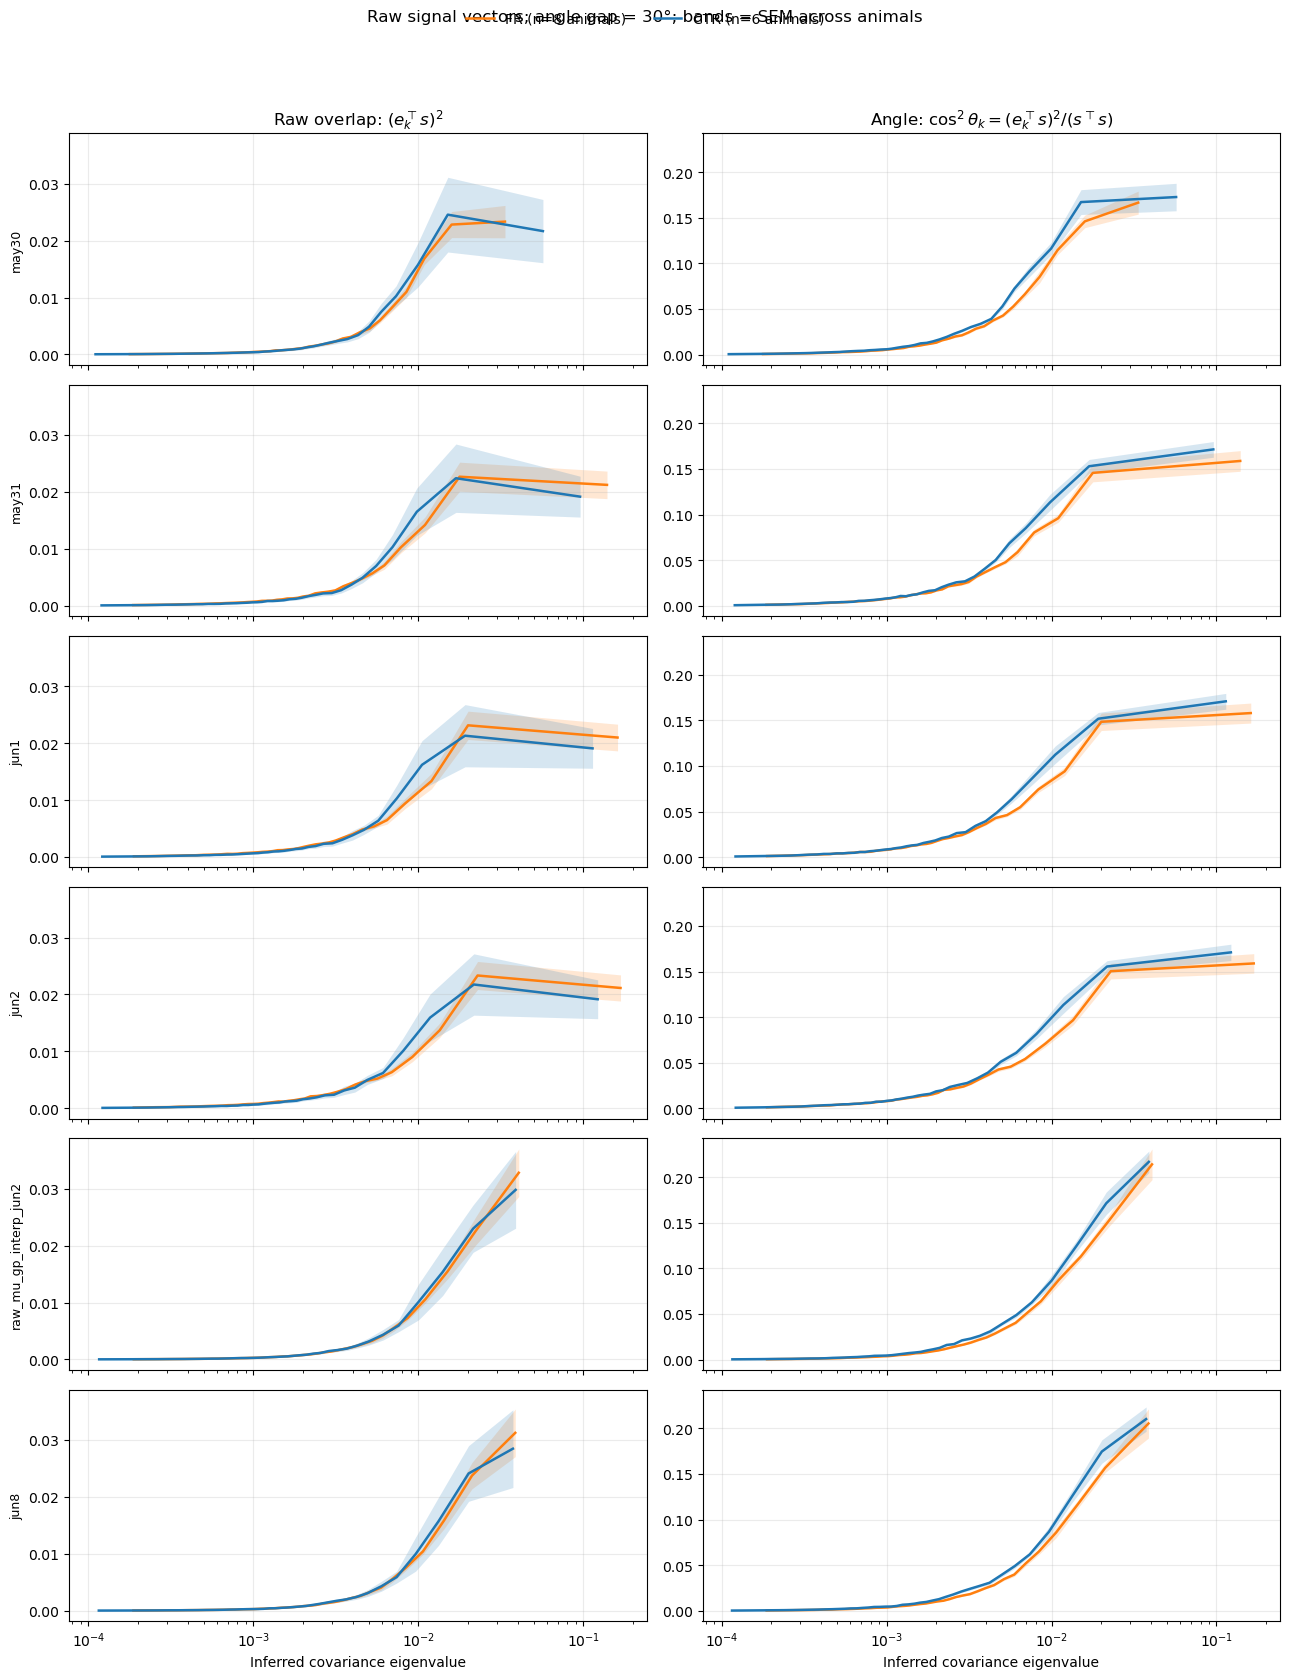

Checked 840 files.
Max |sum_k cos² - 1|: 3.775e-15
Max |sum_k overlap - ||s||²|: 2.776e-15


In [16]:
from pathlib import Path
from collections import defaultdict
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

import z_castedo_snr_script_dynamic as base


# ----------------------------- settings -----------------------------

ROOT = Path.cwd()
ANGLE_GAP_STEPS = 1       # 1 = adjacent measured orientations = 30 degrees
MODE_START = 0            # use 1 to omit the largest-eigenvalue mode
LOG_X = True

GROUP_COLORS = {
    "FR": "tab:orange",
    "CTR": "tab:blue",
}

# Discover the schema-compatible folders explicitly named "static".
STATIC_FOLDERS = sorted(
    (
        folder
        for folder in ROOT.glob("wishart_*static*")
        if folder.is_dir() and any(folder.glob("*_overlaps_eigs.pkl"))
    ),
    key=lambda folder: folder.stat().st_mtime,
)

if not STATIC_FOLDERS:
    raise FileNotFoundError(
        f"No wishart_*static* result folders found in {ROOT.resolve()}"
    )


# ----------------------- reconstruct raw means ----------------------

_inputs_cache = {}
_raw_mean_cache = {}


def raw_condition_mean(d):
    """Return angle x SF x selected-neuron empirical condition means."""

    state = str(d.get("dataset_state", "sated")).lower()
    animal = int(d["animal"])
    start = int(d["start"])
    stop = int(d["stop"])

    cache_key = (state, animal, start, stop)

    if state not in _inputs_cache:
        base.DATASET_STATE = state
        _inputs_cache[state] = base.load_state_inputs()

    if cache_key not in _raw_mean_cache:
        deconv, angle, sf = _inputs_cache[state]

        raw = base.resort_preprocessing(
            deconv, angle, sf, animal
        )[..., start:stop]

        with warnings.catch_warnings():
            # Suppress warnings from padded all-NaN trial positions.
            warnings.simplefilter("ignore", RuntimeWarning)
            resp = np.nanmean(raw, axis=-1).transpose(3, 1, 2, 0)

        # Match preprocessing used when fitting.
        resp = resp[~np.isnan(resp).any(axis=(1, 2, 3))]

        if resp.shape[0] == 0:
            raise ValueError(
                f"No complete trials for animal {animal}, window {start}:{stop}"
            )

        _raw_mean_cache[cache_key] = np.nanmean(resp, axis=0)

    neuron_indices = np.asarray(d["neuron_indices"], dtype=int)
    return _raw_mean_cache[cache_key][..., neuron_indices]


# ----------------------- per-file calculation -----------------------

def calculate_file_metrics(path):
    with path.open("rb") as fh:
        d = pickle.load(fh)

    signal_mean = raw_condition_mean(d)
    n_angles, n_sfs, n_neurons = signal_mean.shape

    if not 1 <= ANGLE_GAP_STEPS < n_angles:
        raise ValueError(
            f"ANGLE_GAP_STEPS must be between 1 and {n_angles - 1}"
        )

    cov = np.asarray(d["sigma_orig_mode"], dtype=float).reshape(
        n_angles, n_sfs, n_neurons, n_neurons
    )

    # Protect against tiny numerical asymmetries.
    cov = 0.5 * (cov + np.swapaxes(cov, -1, -2))

    # Unit eigenvectors; eigh initially returns ascending eigenvalues.
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = eigenvalues[..., ::-1]
    eigenvectors = eigenvectors[..., ::-1]

    # s_i = mu_i - mu_(i + gap), wrapping around orientation.
    sv = signal_mean - np.roll(
        signal_mean,
        -ANGLE_GAP_STEPS,
        axis=0,
    )

    norm2 = np.einsum("asn,asn->as", sv, sv)

    # evecs[angle, sf, neuron, mode].
    projection = np.einsum(
        "asnk,asn->ask",
        eigenvectors,
        sv,
    )

    overlap = np.abs(projection) ** 2

    # Crucially, divide pointwise before doing any averaging.
    cos2 = np.divide(
        overlap,
        norm2[..., None],
        out=np.full_like(overlap, np.nan),
        where=norm2[..., None] > 0,
    )

    valid = norm2 > 0

    # Complete-basis identities used as numerical checks.
    cos_identity_error = (
        np.max(np.abs(np.sum(cos2[valid], axis=-1) - 1.0))
        if np.any(valid)
        else np.nan
    )
    overlap_identity_error = (
        np.max(
            np.abs(
                np.sum(overlap, axis=-1)[valid] - norm2[valid]
            )
        )
        if np.any(valid)
        else np.nan
    )

    group = path.name.split("_", 1)[0]
    if group not in GROUP_COLORS:
        raise ValueError(f"Could not infer FR/CTR group from {path.name}")

    return {
        "dataset": path.parent.name,
        "group": group,
        "animal": int(d["animal"]),
        "repeat": int(d.get("repeat_idx", 0)),
        # Average angle and SF conditions within this saved fit.
        "eigenvalue": np.nanmean(eigenvalues, axis=(0, 1)),
        "overlap": np.nanmean(overlap, axis=(0, 1)),
        "cos2": np.nanmean(cos2, axis=(0, 1)),
        "cos_identity_error": cos_identity_error,
        "overlap_identity_error": overlap_identity_error,
    }


# ------------------------- process all files ------------------------

file_results = []

for folder in STATIC_FOLDERS:
    paths = sorted(folder.glob("*_overlaps_eigs.pkl"))
    print(f"{folder.name}: processing {len(paths)} files")
    file_results.extend(calculate_file_metrics(path) for path in paths)


# First average file repeats within each animal.
runs_by_animal = defaultdict(list)

for result in file_results:
    key = (
        result["dataset"],
        result["group"],
        result["animal"],
    )
    runs_by_animal[key].append(result)


animal_results = []

for (dataset, group, animal), runs in sorted(runs_by_animal.items()):
    n_modes = min(len(run["eigenvalue"]) for run in runs)

    animal_results.append({
        "dataset": dataset,
        "group": group,
        "animal": animal,
        "n_repeats": len(runs),
        "eigenvalue": np.nanmean(
            np.stack([r["eigenvalue"][:n_modes] for r in runs]),
            axis=0,
        ),
        "overlap": np.nanmean(
            np.stack([r["overlap"][:n_modes] for r in runs]),
            axis=0,
        ),
        "cos2": np.nanmean(
            np.stack([r["cos2"][:n_modes] for r in runs]),
            axis=0,
        ),
    })


def mean_and_sem(x):
    """Mean and SEM across animals, allowing NaNs."""

    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    n = finite.sum(axis=0)

    mean = np.divide(
        np.nansum(x, axis=0),
        n,
        out=np.full(x.shape[1:], np.nan),
        where=n > 0,
    )

    ss = np.sum(
        np.where(finite, (x - mean) ** 2, 0.0),
        axis=0,
    )

    sem = np.divide(
        np.sqrt(ss),
        np.sqrt(n * (n - 1)),
        out=np.full_like(mean, np.nan),
        where=n > 1,
    )

    return mean, sem


# Then calculate group means and SEMs across animals.
static_comparison = {}

for folder in STATIC_FOLDERS:
    for group in GROUP_COLORS:
        rows = [
            result
            for result in animal_results
            if result["dataset"] == folder.name
            and result["group"] == group
        ]

        if not rows:
            continue

        n_modes = min(len(row["eigenvalue"]) for row in rows)

        eigenvalues = np.stack([
            row["eigenvalue"][:n_modes] for row in rows
        ])
        overlaps = np.stack([
            row["overlap"][:n_modes] for row in rows
        ])
        cos2_values = np.stack([
            row["cos2"][:n_modes] for row in rows
        ])

        overlap_mean, overlap_sem = mean_and_sem(overlaps)
        cos2_mean, cos2_sem = mean_and_sem(cos2_values)

        static_comparison[(folder.name, group)] = {
            "animals": np.array([row["animal"] for row in rows]),
            "eigenvalue_mean": np.nanmean(eigenvalues, axis=0),
            "overlap_mean": overlap_mean,
            "overlap_sem": overlap_sem,
            "cos2_mean": cos2_mean,
            "cos2_sem": cos2_sem,
        }


# ------------------------------- plot -------------------------------

n_rows = len(STATIC_FOLDERS)

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(13, 2.8 * n_rows),
    sharex="col",
    sharey="col",
    squeeze=False,
)

for row_idx, folder in enumerate(STATIC_FOLDERS):
    for group, color in GROUP_COLORS.items():
        stats = static_comparison.get((folder.name, group))
        if stats is None:
            continue

        modes = np.arange(
            len(stats["eigenvalue_mean"])
        )[MODE_START:]

        x = stats["eigenvalue_mean"][modes]

        # Draw from smaller to larger eigenvalues.
        order = np.argsort(x)
        x = x[order]

        label = f"{group} (n={len(stats['animals'])} animals)"

        for col_idx, metric in enumerate(("overlap", "cos2")):
            y = stats[f"{metric}_mean"][modes][order]
            err = stats[f"{metric}_sem"][modes][order]

            good = np.isfinite(x) & np.isfinite(y)
            if LOG_X:
                good &= x > 0

            axes[row_idx, col_idx].plot(
                x[good],
                y[good],
                color=color,
                linewidth=1.8,
                label=label,
            )

            axes[row_idx, col_idx].fill_between(
                x[good],
                (y - err)[good],
                (y + err)[good],
                color=color,
                alpha=0.18,
                linewidth=0,
            )

    short_name = (
        folder.name
        .removeprefix("wishart_")
        .replace("_static_equal40_sated", "")
    )
    axes[row_idx, 0].set_ylabel(short_name, fontsize=9)

    for ax in axes[row_idx]:
        ax.grid(alpha=0.25)
        if LOG_X:
            ax.set_xscale("log")

axes[0, 0].set_title(r"Raw overlap: $(e_k^\top s)^2$")
axes[0, 1].set_title(
    r"Angle: $\cos^2\theta_k=(e_k^\top s)^2/(s^\top s)$"
)

axes[-1, 0].set_xlabel("Inferred covariance eigenvalue")
axes[-1, 1].set_xlabel("Inferred covariance eigenvalue")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
)

fig.suptitle(
    f"Raw signal vectors; angle gap = "
    f"{30 * ANGLE_GAP_STEPS}°; bands = SEM across animals",
    y=0.997,
)

fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()


# -------------------------- correctness checks ----------------------

max_cos_error = np.nanmax([
    result["cos_identity_error"]
    for result in file_results
])

max_overlap_error = np.nanmax([
    result["overlap_identity_error"]
    for result in file_results
])

print(f"Checked {len(file_results)} files.")
print(f"Max |sum_k cos² - 1|: {max_cos_error:.3e}")
print(f"Max |sum_k overlap - ||s||²|: {max_overlap_error:.3e}")

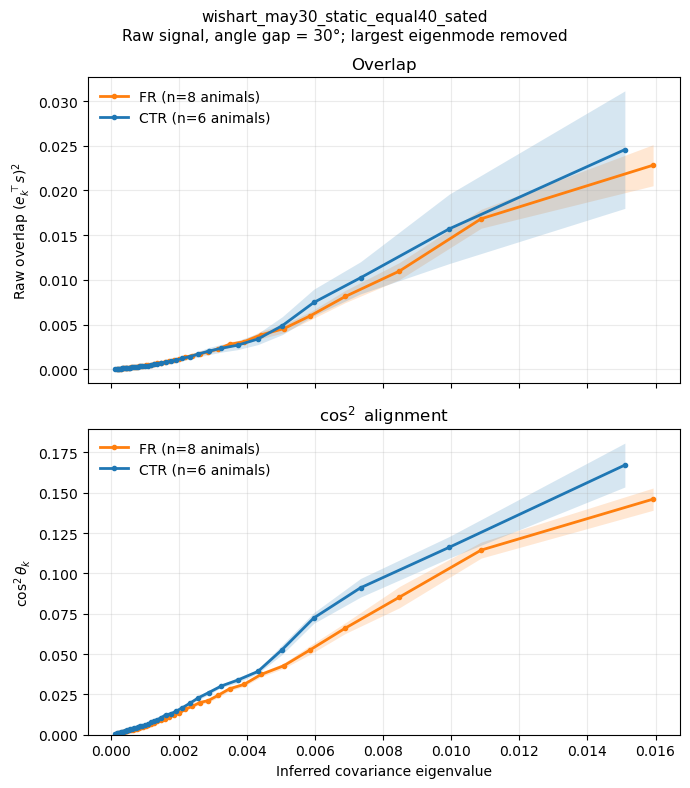

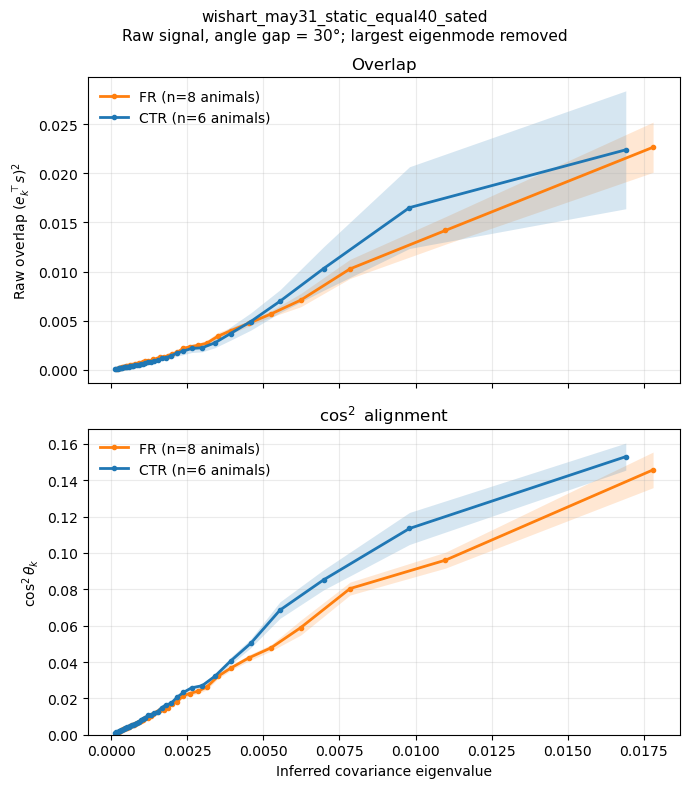

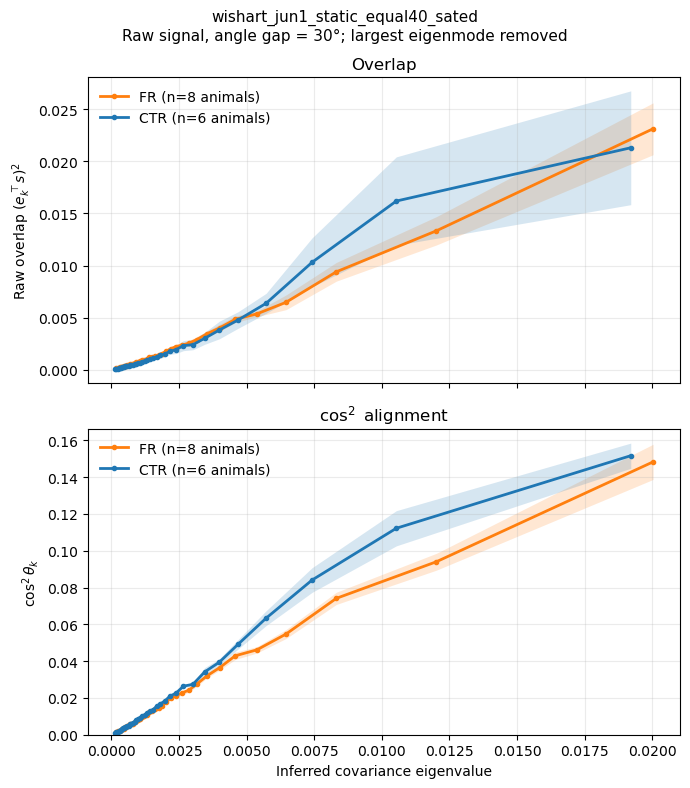

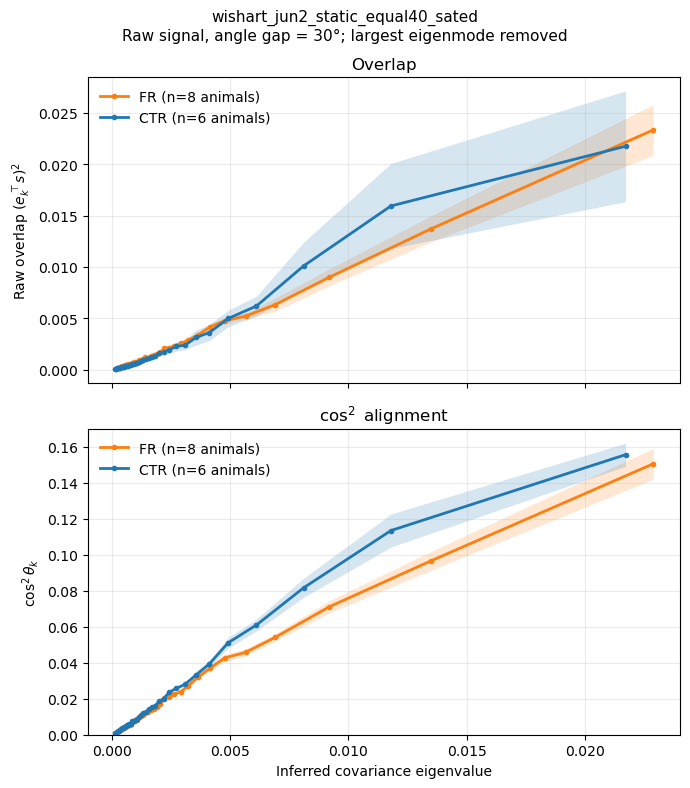

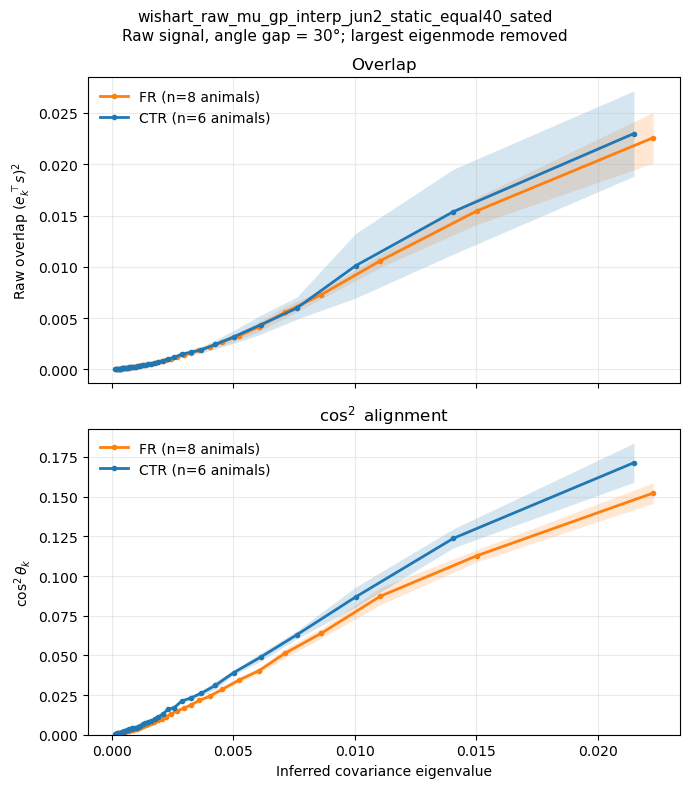

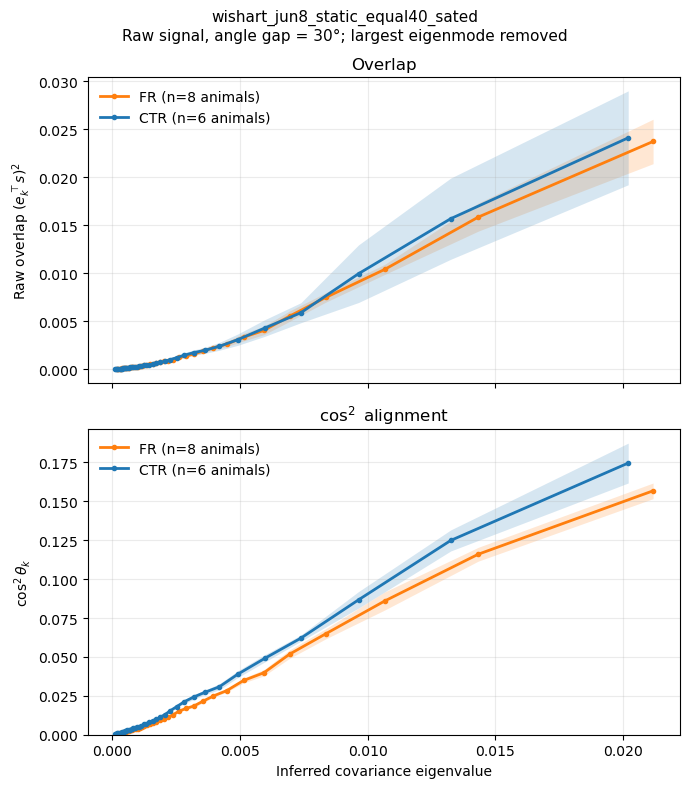

In [18]:
# Plot one figure per dataset:
#   top panel    = overlap
#   bottom panel = cos²
# Eigenmode 0 (largest eigenvalue) is excluded.

REMOVE_TOP_MODES = 1
LOG_X = False

for folder in STATIC_FOLDERS:
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(7, 8),
        sharex=True,
    )

    for group, color in GROUP_COLORS.items():
        stats = static_comparison.get((folder.name, group))
        if stats is None:
            continue

        modes = np.arange(
            REMOVE_TOP_MODES,
            len(stats["eigenvalue_mean"]),
        )

        x = stats["eigenvalue_mean"][modes]
        order = np.argsort(x)
        x = x[order]

        label = f"{group} (n={len(stats['animals'])} animals)"

        # Top: raw overlap
        overlap_mean = stats["overlap_mean"][modes][order]
        overlap_sem = stats["overlap_sem"][modes][order]

        good = np.isfinite(x) & np.isfinite(overlap_mean)
        if LOG_X:
            good &= x > 0

        axes[0].plot(
            x[good],
            overlap_mean[good],
            color=color,
            linewidth=2,
            marker="o",
            markersize=3,
            label=label,
        )
        axes[0].fill_between(
            x[good],
            (overlap_mean - overlap_sem)[good],
            (overlap_mean + overlap_sem)[good],
            color=color,
            alpha=0.18,
            linewidth=0,
        )

        # Bottom: cos²
        cos2_mean = stats["cos2_mean"][modes][order]
        cos2_sem = stats["cos2_sem"][modes][order]

        good = np.isfinite(x) & np.isfinite(cos2_mean)
        if LOG_X:
            good &= x > 0

        axes[1].plot(
            x[good],
            cos2_mean[good],
            color=color,
            linewidth=2,
            marker="o",
            markersize=3,
            label=label,
        )
        axes[1].fill_between(
            x[good],
            (cos2_mean - cos2_sem)[good],
            (cos2_mean + cos2_sem)[good],
            color=color,
            alpha=0.18,
            linewidth=0,
        )

    axes[0].set_ylabel(r"Raw overlap $(e_k^\top s)^2$")
    axes[1].set_ylabel(r"$\cos^2\theta_k$")
    axes[1].set_xlabel("Inferred covariance eigenvalue")

    axes[0].set_title("Overlap")
    axes[1].set_title(r"$\cos^2$ alignment")
    axes[1].set_ylim(bottom=0)

    for ax in axes:
        if LOG_X:
            ax.set_xscale("log")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)

    fig.suptitle(
        f"{folder.name}\n"
        f"Raw signal, angle gap = {30 * ANGLE_GAP_STEPS}°; "
        f"largest eigenmode removed",
        fontsize=11,
    )

    fig.tight_layout()
    plt.show()

In [19]:
from pathlib import Path
import numpy as np

dataset = "wishart_jun8_static_equal40_sated"
fr = static_comparison[(dataset, "FR")]
ctr = static_comparison[(dataset, "CTR")]

keep = slice(1, None)  # remove top eigenmode

output_file = Path("jun8_overlap_cos2_no_top_mode.npz")

np.savez_compressed(
    output_file,
    fr_eigenvalue=fr["eigenvalue_mean"][keep],
    fr_overlap=fr["overlap_mean"][keep],
    fr_overlap_sem=fr["overlap_sem"][keep],
    fr_cos2=fr["cos2_mean"][keep],
    fr_cos2_sem=fr["cos2_sem"][keep],
    ctr_eigenvalue=ctr["eigenvalue_mean"][keep],
    ctr_overlap=ctr["overlap_mean"][keep],
    ctr_overlap_sem=ctr["overlap_sem"][keep],
    ctr_cos2=ctr["cos2_mean"][keep],
    ctr_cos2_sem=ctr["cos2_sem"][keep],
)

print(f"Saved: {output_file.resolve()}")

Saved: /home/scastedo/wishart-process/jun8_overlap_cos2_no_top_mode.npz
